<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M_11_A_8_Supervised_Learning_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 8: Supervised Learning Classification
#Name Ayleen Santander

#Part 1: Dataset Selection and Preprocessing:
1. Choose a publicly Source: Google Dataset Search|Dataset name: AI in Software Development Statistics 2026. In this data I will predict salary for LLM engineer.
- What does an LLM Engineer actually make in 2026,and does using AI tools every day pay you more or price you out?
- Conduct necessary preprocessing steps such as:
1. Cleaning data by handling missing values and removing duplicates
2. Converting categorical data using encoding techniques
3. Splitting the dataset into training and testing sets

In [52]:
#Libraries
from mlxtend.plotting import plot_decision_regions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from scipy.stats import chi2_contingency
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, auc
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [53]:
#Part 1: Dataset Selection and Preprocessing
#Loading the dataset
aijobs = pd.read_csv('ai_ds_job_salaries_2026.csv', nrows= 1000)

#Print the first 5 rows of the dataframe.
aijobs.head()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,primary_language,has_ml_in_title,manages_people,team_size,certifications_count,weekly_hours,uses_ai_tools_daily,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,Python,False,True,5,0,48.0,True,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,SQL,True,False,6,1,41.6,False,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,Python,True,False,4,1,55.1,True,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,Java,False,False,6,2,41.1,True,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,Python,False,False,13,2,48.2,False,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


In [54]:
aijobs.info()
aijobs.shape
aijobs.dtypes
print('=='* 45)
aijobs.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   1000 non-null   object 
 1   experience_level            1000 non-null   object 
 2   employment_type             1000 non-null   object 
 3   company_size                1000 non-null   object 
 4   company_location            1000 non-null   object 
 5   employee_residence          1000 non-null   object 
 6   industry                    1000 non-null   object 
 7   remote_ratio                1000 non-null   int64  
 8   years_experience            1000 non-null   float64
 9   education_level             1000 non-null   object 
 10  primary_language            1000 non-null   object 
 11  has_ml_in_title             1000 non-null   bool   
 12  manages_people              1000 non-null   bool   
 13  team_size                   1000 n

,count,mean,std,min,25%,50%,75%,max
remote_ratio,1000.0,44.150000,41.048294,0.0,0.000,50.000,100.000,100.000
years_experience,1000.0,8.582400,4.901213,0.0,4.900,8.150,11.900,22.800
team_size,1000.0,7.951000,2.618292,1.0,6.000,8.000,10.000,18.000
certifications_count,1000.0,1.881000,1.328384,0.0,1.000,2.000,3.000,8.000
weekly_hours,1000.0,44.474900,5.957200,24.7,40.275,44.400,48.725,67.300
ai_tools_hours_per_week,1000.0,8.286600,5.487784,0.0,3.200,8.300,12.525,25.000
salary_usd,1000.0,100823.421000,54578.467348,12000.0,60049.750,92615.000,131834.250,329944.000
equity_offered_pct,1000.0,0.137186,0.183228,0.0,0.020,0.071,0.173,1.264
bonus_pct,1000.0,10.987300,5.204542,0.0,7.300,10.850,14.500,26.200
job_satisfaction_score,1000.0,6.659500,1.310820,3.1,5.700,6.700,7.500,10.000


In [55]:
# Count unique values per column — the key diagnostic
for col in aijobs.columns:
    print(f"{col:10} | unique: {aijobs[col].nunique():4} | dtype: {aijobs[col].dtype}")

job_title  | unique:   12 | dtype: object
experience_level | unique:    5 | dtype: object
employment_type | unique:    4 | dtype: object
company_size | unique:    3 | dtype: object
company_location | unique:   12 | dtype: object
employee_residence | unique:   12 | dtype: object
industry   | unique:   10 | dtype: object
remote_ratio | unique:    3 | dtype: int64
years_experience | unique:  202 | dtype: float64
education_level | unique:    5 | dtype: object
primary_language | unique:    7 | dtype: object
has_ml_in_title | unique:    2 | dtype: bool
manages_people | unique:    2 | dtype: bool
team_size  | unique:   17 | dtype: int64
certifications_count | unique:    8 | dtype: int64
weekly_hours | unique:  256 | dtype: float64
uses_ai_tools_daily | unique:    2 | dtype: bool
ai_tools_hours_per_week | unique:  203 | dtype: float64
salary_currency | unique:    9 | dtype: object
salary_usd | unique:  997 | dtype: int64
equity_offered_pct | unique:  358 | dtype: float64
bonus_pct  | unique:  

In [56]:
#Part 1: Dataset Selection and Preprocessing
#1.Cleaning data by handling missing values and removing duplicates
# Null check
nulls = aijobs.isnull().sum()
print("Nulls per column:")
print(nulls)
print(f"\nTotal nulls: {nulls.sum()}")

print('=='* 45)
# Duplicates are worth checking too
print(f"Duplicate rows: {aijobs.duplicated().sum()}")

print('=='* 45)
# Overall structure
print(type(aijobs))

Nulls per column:
job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

Total nulls: 0
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>


In [57]:
#2. Splitting the dataset into training and testing sets
#Define wich columns are the features and targets, create a list of the columns for X and for Y
#feature
feature = ['job_title','experience_level','employment_type','industry','remote_ratio',
           'years_experience','education_level','uses_ai_tools_daily','ai_tools_hours_per_week',
           'fears_ai_automation_score']
#target
target = ['salary_usd']

X = aijobs[feature]
y = aijobs[target]

print(X.shape, y.shape)

(1000, 10) (1000, 1)


#Part 2: Exploratory Data Analysis (EDA) - AI Jobs Dataset
1. Distribution of classes
2. Correlation between features
3. Any insights into the data that may affect the choice of classifier or the classification accuracy

In [58]:
#Define X (features) and y (target) and perform the train-test split:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_theme(style='whitegrid')

features = ["job_title", "experience_level", "employment_type", "industry", "remote_ratio",
    "years_experience", "education_level", "uses_ai_tools_daily",
    "ai_tools_hours_per_week", "fears_ai_automation_score",
]
target = 'salary_usd'

df = aijobs[features + [target]].copy()
print(df.columns.tolist())

['job_title', 'experience_level', 'employment_type', 'industry', 'remote_ratio', 'years_experience', 'education_level', 'uses_ai_tools_daily', 'ai_tools_hours_per_week', 'fears_ai_automation_score', 'salary_usd']


In [59]:
# 1. Structural check
print("Shape:", df.shape)
print('=='*45)
print("Duplicates:", df.duplicated().sum())
print('=='*45)
print("\nMissing values:", df.isna().sum().sum())
print('=='*45)
print("\nUnique values per column:")
print(df.nunique().sort_values())
print()
print('=='*45)
df.head()

Shape: (1000, 11)
Duplicates: 0

Missing values: 0

Unique values per column:
uses_ai_tools_daily            2
remote_ratio                   3
employment_type                4
experience_level               5
education_level                5
industry                      10
job_title                     12
fears_ai_automation_score     85
years_experience             202
ai_tools_hours_per_week      203
salary_usd                   997
dtype: int64



,job_title,experience_level,employment_type,industry,remote_ratio,years_experience,education_level,uses_ai_tools_daily,ai_tools_hours_per_week,fears_ai_automation_score,salary_usd
0,Data Analyst,Lead,Part-time,Finance,0,14.4,Bachelors,True,12.5,7.4,23844
1,Research Scientist,Senior,Full-time,Retail,50,7.6,Masters,False,2.1,5.3,170132
2,Machine Learning Engineer,Entry,Full-time,Government,0,0.0,Bootcamp,True,5.1,6.8,83059
3,Data Engineer,Senior,Full-time,Government,100,9.7,Masters,True,2.0,5.0,29531
4,Data Engineer,Mid,Full-time,Education,0,3.2,Bachelors,False,4.0,5.1,70105


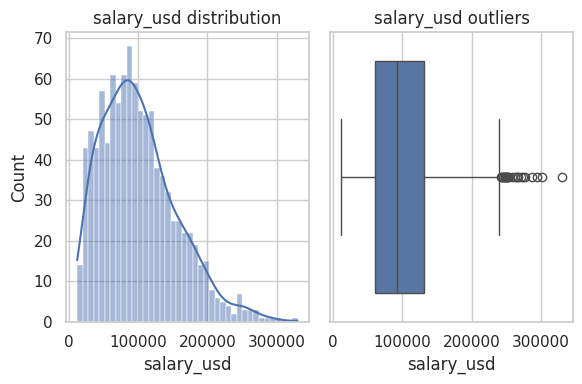

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
sns.histplot(df[target], bins=40, kde=True, ax=axes[0])
axes[0].set_title("salary_usd distribution")
sns.boxplot(x=df[target], ax=axes[1])
axes[1].set_title("salary_usd outliers")
plt.tight_layout()
plt.show()

In [61]:
# 3. Distribution of classes
# Bin into three balanced classes at the 33rd and 67th percentiles
df["salary_band"] = pd.qcut(df[target], q=3, labels=["Low", "Medium", "High"])
CLASS = "salary_band"

cut_points = pd.qcut(df[target], q=3, retbins=True)[1]
print("Class boundaries (USD):", np.round(cut_points).astype(int).tolist())

counts = df[CLASS].value_counts().sort_index()
pcts = df[CLASS].value_counts(normalize=True).sort_index().mul(100).round(2)
print("\n", pd.DataFrame({"count": counts, "percent": pcts}), sep="")
print(f"\nBaseline accuracy (majority class): {pcts.max():.2f}%")
print(f"Imbalance ratio: {counts.max() / counts.min():.2f} : 1")

Class boundaries (USD): [12000, 71730, 117271, 329944]

             count  percent
salary_band                
Low            334     33.4
Medium         332     33.2
High           334     33.4

Baseline accuracy (majority class): 33.40%
Imbalance ratio: 1.01 : 1


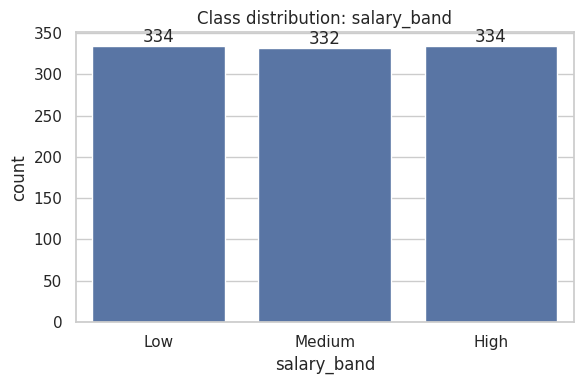

In [62]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=CLASS, data=df, order=["Low", "Medium", "High"], ax=ax)
for c in ax.containers:
    ax.bar_label(c, fmt="%d")
ax.set_title("Class distribution: salary_band")
plt.tight_layout()
plt.show()

['remote_ratio', 'years_experience', 'ai_tools_hours_per_week', 'fears_ai_automation_score', 'salary_usd']
                            count       mean       std      min       25%  \
remote_ratio               1000.0      44.15     41.05      0.0      0.00   
years_experience           1000.0       8.58      4.90      0.0      4.90   
ai_tools_hours_per_week    1000.0       8.29      5.49      0.0      3.20   
fears_ai_automation_score  1000.0       4.78      1.74      1.0      3.50   
salary_usd                 1000.0  100823.42  54578.47  12000.0  60049.75   

                                50%        75%       max  
remote_ratio                  50.00     100.00     100.0  
years_experience               8.15      11.90      22.8  
ai_tools_hours_per_week        8.30      12.52      25.0  
fears_ai_automation_score      4.80       6.00      10.0  
salary_usd                 92615.00  131834.25  329944.0  


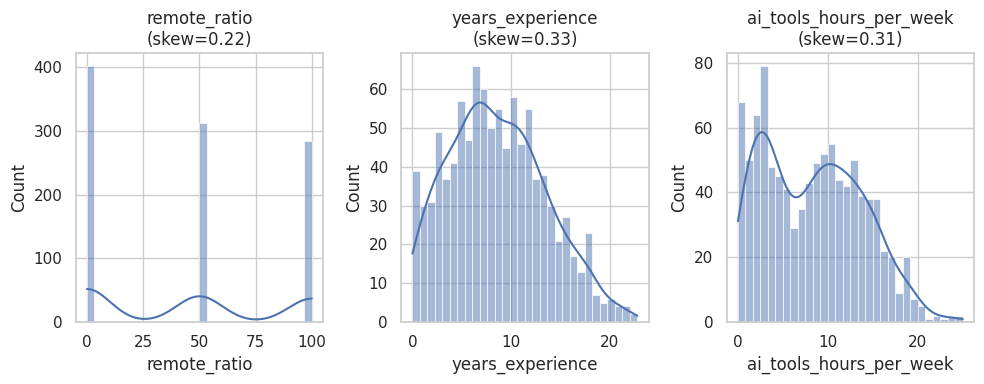

In [66]:
#3. Numeric feature distributions
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(numeric_cols)
print(df[numeric_cols].describe().T.round(2))

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"{col}\n(skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()


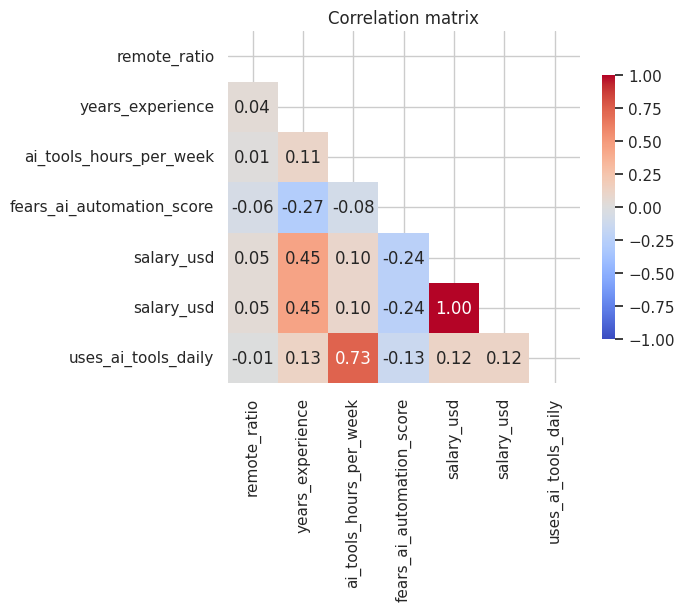

In [67]:
#4. Correlation between features
# Encode booleans so they join the numeric correlation matrix
corr_df = df[numeric_cols + [target]].copy()
corr_df["uses_ai_tools_daily"] = df["uses_ai_tools_daily"].astype(int)
corr_df["remote_ratio"] = df["remote_ratio"]
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

In [92]:
# bare string, not a list
target = 'salary_usd'

# guards against the duplicate-column TypeError from earlier
df = df.loc[:, ~df.columns.duplicated()]

numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='category').columns.tolist()
bool_cols = df.select_dtypes(include='bool').columns.tolist()
print(numeric_cols)
print(categorical_cols)
print(bool_cols)
print('=='*45)

assert target in numeric_cols, f"{target} not found in numeric columns"

corr = df[numeric_cols].corr()

target_corr = corr[target].drop(target).sort_values(key=abs, ascending=False)
print(f"\nCorrelation with {target}:")
print(target_corr.round(3))

others = corr.drop(index=target, columns=target)
mask = np.triu(np.ones(others.shape, dtype=bool), k=1)

pairs = (others.where(mask)
              .stack().rename("corr").reset_index()
              .rename(columns={"level_0": "feature_1", "level_1": "feature_2"}))
pairs["abs_corr"] = pairs["corr"].abs()

print('==' * 45)
print("\nFeature-to-feature pairs, strongest first:")
print(pairs.sort_values("abs_corr", ascending=False)
           .drop(columns="abs_corr")
           .round(3).head(10).to_string(index=False))

['remote_ratio', 'years_experience', 'ai_tools_hours_per_week', 'fears_ai_automation_score', 'salary_usd']
['salary_band']
['uses_ai_tools_daily']

Correlation with salary_usd:
years_experience             0.447
fears_ai_automation_score   -0.237
ai_tools_hours_per_week      0.099
remote_ratio                 0.047
Name: salary_usd, dtype: float64

Feature-to-feature pairs, strongest first:
              feature_1                 feature_2   corr
       years_experience fears_ai_automation_score -0.275
       years_experience   ai_tools_hours_per_week  0.111
ai_tools_hours_per_week fears_ai_automation_score -0.081
           remote_ratio fears_ai_automation_score -0.060
           remote_ratio          years_experience  0.039
           remote_ratio   ai_tools_hours_per_week  0.008


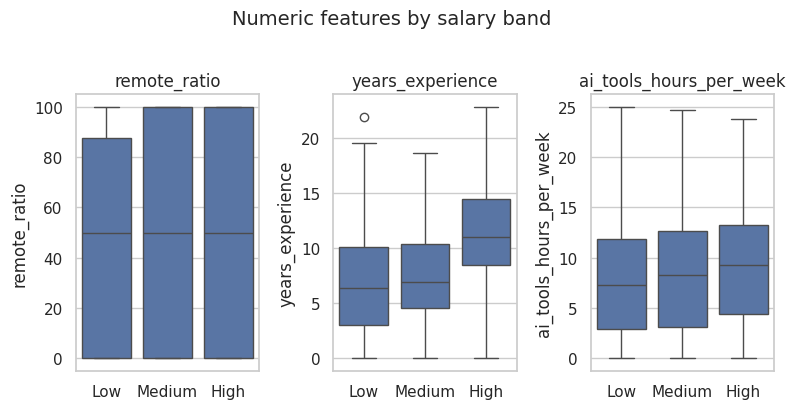

In [93]:
#5. Numeric features vs. the salary band
fig, axes = plt.subplots(1, 3, figsize=(8, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=CLASS, y=col, data=df, order=["Low", "Medium", "High"], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Numeric features by salary band", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [94]:
# Bigger spread across bands = stronger predictor
band_means = df.groupby(CLASS, observed=True)[numeric_cols].mean().T
band_means["spread"] = band_means.max(axis=1) - band_means.min(axis=1)
print(band_means.round(3).sort_values("spread", ascending=False))

salary_band                      Low     Medium        High      spread
salary_usd                 45917.329  93552.807  162956.590  117039.260
years_experience               6.921      7.450      11.369       4.448
remote_ratio                  41.916     44.729      45.808       3.892
ai_tools_hours_per_week        7.664      8.196       8.999       1.334
fears_ai_automation_score      5.117      4.900       4.323       0.793


In [95]:
#6. Categorical features vs. salary
low_card = ["experience_level", "employment_type", "education_level",
            "remote_ratio", "uses_ai_tools_daily"]

for col in low_card:
    stats = (df.groupby(col, observed=True)[target]
               .agg(n="size", mean_salary="mean", median_salary="median")
               .round(0).sort_values("mean_salary", ascending=False))
    print(f"\n--- {col} ---")
    print('=='*45)
    print(stats)


--- experience_level ---
                    n  mean_salary  median_salary
experience_level                                 
Executive          53     157613.0       173856.0
Lead              149     130304.0       124586.0
Senior            297     113860.0       113539.0
Mid               312      87853.0        88482.0
Entry             189      62582.0        63639.0

--- employment_type ---
                   n  mean_salary  median_salary
employment_type                                 
Full-time        833     103929.0        95682.0
Freelance         35      99065.0        97739.0
Contract          94      92247.0        88429.0
Part-time         38      55575.0        48722.0

--- education_level ---
                   n  mean_salary  median_salary
education_level                                 
PhD              100     117520.0       107664.0
Masters          358     105163.0        99860.0
Bachelors        383      97006.0        87121.0
Self-taught       63      93881.0  

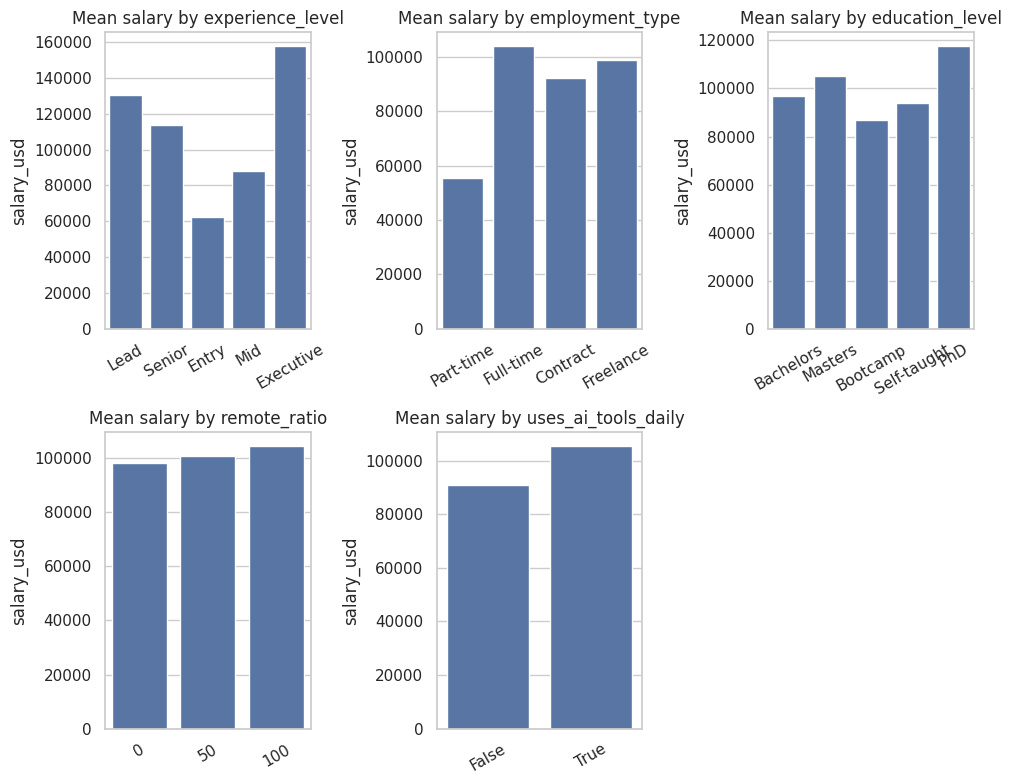

In [96]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.ravel()
for ax, col in zip(axes, low_card):
    sns.barplot(x=col, y=target, data=df, ax=ax, errorbar=None)
    ax.set_title(f"Mean salary by {col}")
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


In [97]:
# High-cardinality columns: job_title and industry
for col in ["job_title", "industry"]:
    print(f"\n--- {col}: {df[col].nunique()} unique values ---")
    stats = (df.groupby(col, observed=True)[target]
               .agg(n="size", mean_salary="mean")
               .round(0).sort_values("mean_salary", ascending=False))
    print(stats.head(10))
    print("=="*45)
    print(stats.tail(5))


--- job_title: 12 unique values ---
                             n  mean_salary
job_title                                  
Data Science Manager        53     125546.0
Machine Learning Engineer  120     119389.0
AI Engineer                110     118526.0
Computer Vision Engineer    48     114878.0
Research Scientist          49     109334.0
LLM Engineer                43     105424.0
Analytics Engineer          80      98179.0
Data Engineer              131      97991.0
MLOps Engineer              58      95918.0
Data Scientist             132      92874.0
                                 n  mean_salary
job_title                                      
Data Engineer                  131      97991.0
MLOps Engineer                  58      95918.0
Data Scientist                 132      92874.0
Business Intelligence Analyst   62      75365.0
Data Analyst                   114      72051.0

--- industry: 10 unique values ---
                 n  mean_salary
industry                       

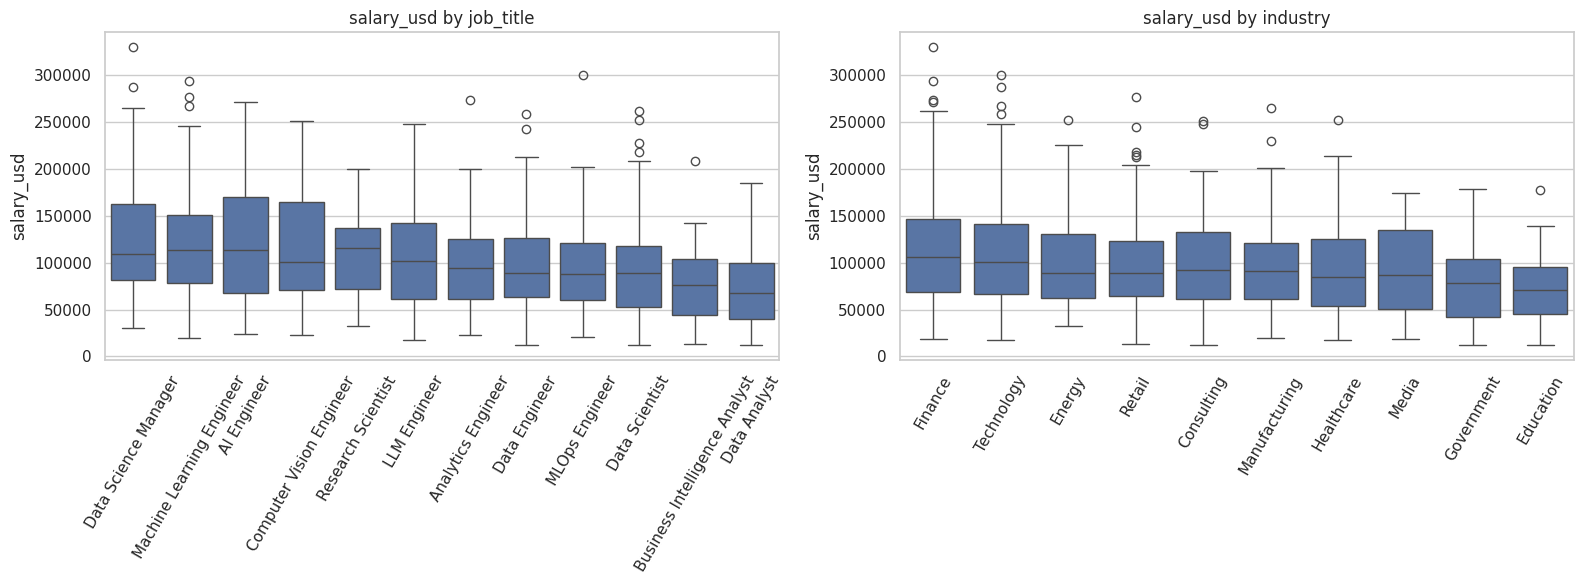

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes, ["job_title", "industry"]):
    order = df.groupby(col, observed=True)[target].mean().sort_values(ascending=False).index
    sns.boxplot(x=col, y=target, data=df, order=order, ax=ax)
    ax.set_title(f"salary_usd by {col}")
    ax.tick_params(axis="x", rotation=60)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [99]:
# Cramer's V: association between each categorical feature and the salary band
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if min(ct.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

assoc = (pd.Series({c: cramers_v(df[c], df[CLASS]) for c in categorical_cols + bool_cols}).sort_values(ascending=False).rename("cramers_v"))
print(assoc.round(3))
print("\n0.0-0.1 negligible | 0.1-0.3 weak | 0.3-0.5 moderate | >0.5 strong")

salary_band            1.000
uses_ai_tools_daily    0.126
Name: cramers_v, dtype: float64

0.0-0.1 negligible | 0.1-0.3 weak | 0.3-0.5 moderate | >0.5 strong


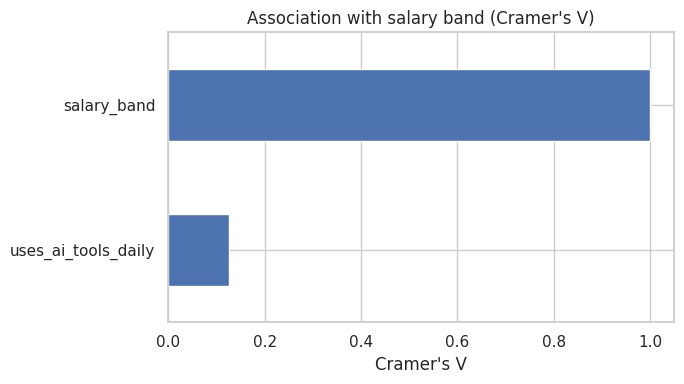

In [100]:
fig, ax = plt.subplots(figsize=(7, 4))
assoc.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Association with salary band (Cramer's V)")
ax.set_xlabel("Cramer's V")
plt.tight_layout()
plt.show()

Interpretation: 0.12 is a weak association. Rough guide for Cramér's V — under 0.1 negligible, 0.1–0.3 weak, 0.3–0.5 moderate, above 0.5 strong. So daily AI tool use tells you very little about which salary band someone lands in, which is itself a finding worth a line in your write-up.

remote_ratio                 0.053
ai_tools_hours_per_week      0.080
education_level              0.092
uses_ai_tools_daily          0.126
fears_ai_automation_score    0.134
industry                     0.137
employment_type              0.147
job_title                    0.196
years_experience             0.297
experience_level             0.337
dtype: float64


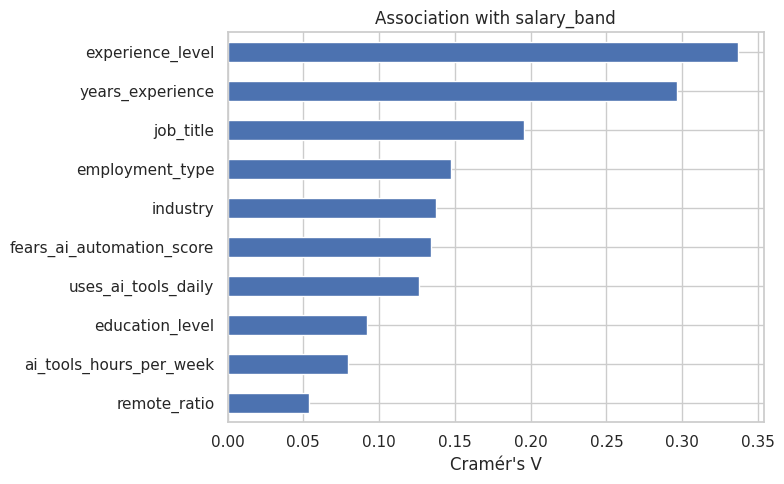

In [121]:
#Cramer's V associate with all categories vs salary
def cramers_v(x, y):
    t = pd.crosstab(x, y)
    chi2 = chi2_contingency(t)[0]
    n = t.values.sum()
    return np.sqrt((chi2 / n) / (min(t.shape) - 1))

target = 'salary_band'

# every column except salary itself; numeric ones get binned
X = df.drop(columns=[target, 'salary_usd'], errors='ignore').copy()
for c in X.select_dtypes(include='number'):
    X[c] = pd.qcut(X[c], 4, duplicates='drop')

scores = pd.Series({c: cramers_v(X[c], df[target]) for c in X}).sort_values()

print(scores.round(3))

scores.plot(kind='barh', figsize=(8, 5))
plt.xlabel("Cramér's V")
plt.title(f"Association with {target}")
plt.tight_layout()
plt.show()

Interpretation: experience_level (0.34) and years_experience (0.30) sit clearly above everything else. Both are measuring the same underlying thing, which is a good consistency check: the categorical seniority label and the raw years agree. Moderate association by conventional cutoffs.

job_title (0.20) is third, but read it cautiously, job title likely has many categories, and Cramér's V inflates with high cardinality on a limited sample. Its real signal is probably a bit lower than 0.20.

Then a flat middle band from 0.13 to 0.15: employment_type, industry, fears_ai_automation_score, uses_ai_tools_daily. These differences are small enough that the ordering among them isn't meaningful — treat them as one tier of weak association.

education_level (0.09), ai_tools_hours_per_week (0.08), and remote_ratio (0.05) are negligible.

The AI-related variables (uses_ai_tools_daily, ai_tools_hours_per_week, fears_ai_automation_score) all land in weak-to-negligible territory. If this dataset is about AI's effect on salaries, that's a real result, AI tool usage barely moves salary band once you look at it directly. Experience does the work.


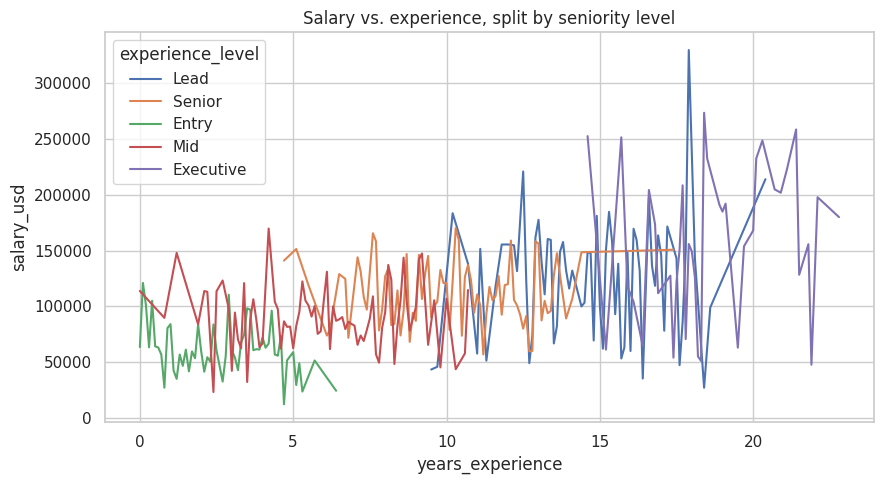

In [101]:
# 7. Interaction check
# Does experience pay off differently depending on the role?
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(x="years_experience", y=target, hue="experience_level",
             data=df, errorbar=None, ax=ax)
ax.set_title("Salary vs. experience, split by seniority level")
plt.tight_layout()
plt.show()

Interpretation: Line Chart shows how the years experience has strong relation with salary, each line represent each experience level, Entry level start 0 to 7 years experience and salary start $60k maximum $120k average and then Mid Level go throw 11 years experience and the maximum salary $155k per years, then after 12 years experience Senior with maximum salary per year $160k, Lead over 20 maximun salary per year $350k and Executive over 23 year experience and maximum salary $280k per year. Previous I compare the experience vs academic level in this chart shows only years experience we need to considerate the experience and the academic level vs salary because high experience and high academic level impact in our salary.

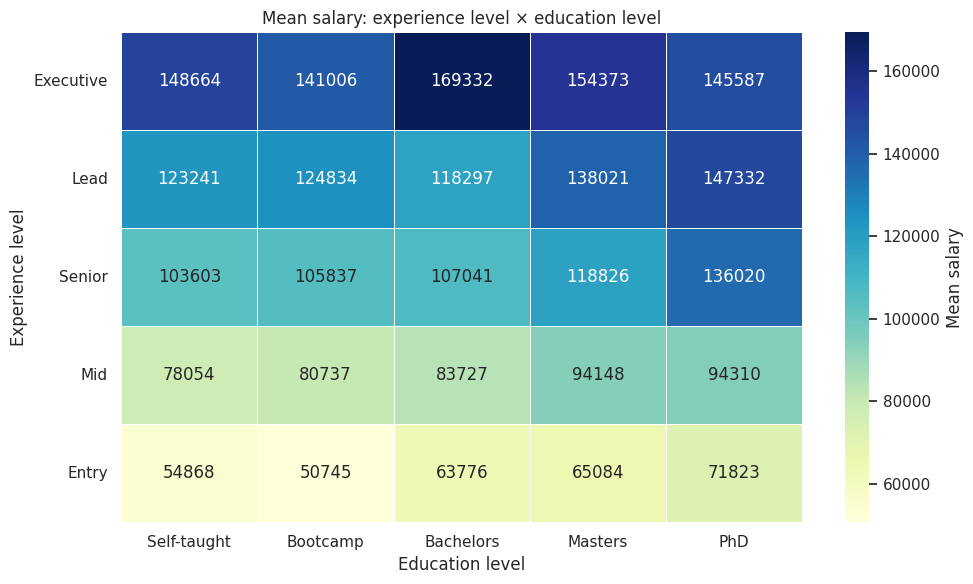

In [102]:
# Heat Map/ Logical order instead of alphabetical
exp_order = ['Executive', 'Lead', 'Senior', 'Mid', 'Entry']
edu_order = ['Self-taught', 'Bootcamp', 'Bachelors', 'Masters', 'PhD']

pivot = df.pivot_table(
    index='experience_level',
    columns='education_level',
    values='salary_usd',
    aggfunc='mean'
).reindex(index=exp_order, columns=edu_order)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label': 'Mean salary'})

plt.title('Mean salary: experience level × education level')
plt.xlabel('Education level')
plt.ylabel('Experience level')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Interpretation: Heatmap shows very clear seniority level + education level impact in our salary level, the high seniority level + high education level our salary band will be the top per year.

Interpretation: Experience level (0.337), is the only moderate association. Everything else is weak or negligible. The salary spread across seniority levels was much wider than across education levels.
job title(0.196), employment type(0.147), industry (0.137), uses ai toosl daily(0.126) all sit in weak territory. They carry same signal but not much individually.
Education level (0.092) and remore ratio(0.047) are effectively noise with respect to the target. Again consistent with the heatmap: within any experience row, the education columns didnt vary nearly as much as they did down the seniority axis.

In [103]:
#8. Summary
print(f"""
EDA SUMMARY
-----------
Rows / features        : {df.shape[0]} / {len(features)}
Target                 : {target} (continuous, binned into 3 classes)
Class boundaries       : {np.round(cut_points).astype(int).tolist()}
Class counts           : {dict(counts)}
Baseline accuracy      : {pcts.max():.2f}%
Missing values         : {int(df[features].isna().sum().sum())}
Strongest numeric      : {target_corr.abs().idxmax()} (r = {target_corr.loc[target_corr.abs().idxmax()]:.3f})
Strongest categorical  : {assoc.idxmax()} (V = {assoc.max():.3f})
Weakest overall        : {assoc.idxmin()} (V = {assoc.min():.3f})
job_title levels       : {df['job_title'].nunique()}
industry levels        : {df['industry'].nunique()}
""")


EDA SUMMARY
-----------
Rows / features        : 1000 / 10
Target                 : salary_usd (continuous, binned into 3 classes)
Class boundaries       : [12000, 71730, 117271, 329944]
Class counts           : {'Low': np.int64(334), 'Medium': np.int64(332), 'High': np.int64(334)}
Baseline accuracy      : 33.40%
Missing values         : 0
Strongest numeric      : years_experience (r = 0.447)
Strongest categorical  : salary_band (V = 1.000)
Weakest overall        : uses_ai_tools_daily (V = 0.126)
job_title levels       : 12
industry levels        : 10



#Part 3: Model Implementation and Evaluation:
1. Implement at least two classification models (e.g., Logistic Regression, Support Vector Machines, Decision Trees, Random Forests, k-Nearest Neighbors).
2. Train the models on the training data.
3. Evaluate the models on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [104]:
CLASS_NAMES = ["Low", "Medium", "High"]
RANDOM_STATE = 42

# X = independent features (everything except the target)
# y = target variable
features= [
    "job_title", "experience_level", "employment_type", "industry", "remote_ratio",
    "years_experience", "education_level", "uses_ai_tools_daily",
    "ai_tools_hours_per_week", "fears_ai_automation_score",
]

data = aijobs[features + ["salary_usd"]].copy()
data["salary_band"] = pd.qcut(data["salary_usd"], q=3, labels=CLASS_NAMES)

X = data[features]
y = pd.Categorical(data["salary_band"], categories=CLASS_NAMES, ordered=True).codes

In [105]:
#80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Test class counts:", dict(zip(CLASS_NAMES, np.bincount(y_test))))

baseline = max(np.bincount(y_test)) / len(y_test)
print(f"Baseline accuracy: {baseline:.4f}")

Train: (800, 10) | Test: (200, 10)
Test class counts: {'Low': np.int64(67), 'Medium': np.int64(66), 'High': np.int64(67)}
Baseline accuracy: 0.3350


In [106]:
X_train.head()

,job_title,experience_level,employment_type,industry,remote_ratio,years_experience,education_level,uses_ai_tools_daily,ai_tools_hours_per_week,fears_ai_automation_score
536,AI Engineer,Entry,Full-time,Technology,0,0.0,Masters,True,2.6,8.5
321,LLM Engineer,Senior,Full-time,Technology,0,8.0,Masters,True,4.7,1.2
41,Data Engineer,Executive,Full-time,Technology,100,17.3,Masters,True,8.8,3.2
305,Data Engineer,Lead,Part-time,Healthcare,100,15.7,Bachelors,False,2.7,4.3
983,Data Scientist,Senior,Full-time,Retail,100,11.5,Masters,False,2.6,5.0


In [107]:
X_test.head()

,job_title,experience_level,employment_type,industry,remote_ratio,years_experience,education_level,uses_ai_tools_daily,ai_tools_hours_per_week,fears_ai_automation_score
361,Data Analyst,Senior,Freelance,Technology,0,11.3,Bachelors,True,13.1,6.0
128,Machine Learning Engineer,Entry,Full-time,Healthcare,0,1.7,PhD,True,20.0,8.1
643,Data Scientist,Entry,Full-time,Education,0,5.3,Masters,False,3.3,3.3
508,Machine Learning Engineer,Senior,Full-time,Technology,0,6.2,Bachelors,True,16.1,2.4
717,Research Scientist,Senior,Part-time,Healthcare,0,8.1,Masters,True,7.4,4.5


In [108]:
y_train

array([0, 2, 1, 0, 1, 2, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 2, 2, 0, 2, 2, 0,
       0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 1, 1, 1, 1, 2, 0, 0, 2, 1, 2, 1,
       0, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 1, 1, 1, 2, 2, 0, 2, 0, 2, 1, 0,
       2, 1, 2, 0, 0, 1, 1, 1, 1, 1, 2, 1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2,
       0, 1, 0, 1, 0, 0, 2, 2, 2, 0, 1, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       2, 0, 1, 2, 0, 2, 1, 0, 0, 2, 0, 2, 1, 0, 1, 1, 0, 1, 1, 0, 1, 2,
       1, 2, 2, 0, 0, 1, 0, 1, 2, 0, 0, 1, 0, 1, 2, 1, 2, 1, 2, 0, 2, 1,
       1, 0, 1, 0, 2, 2, 0, 2, 2, 2, 0, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 0,
       1, 2, 2, 0, 0, 0, 2, 0, 0, 0, 1, 0, 2, 0, 1, 2, 0, 2, 0, 2, 2, 1,
       2, 1, 2, 0, 1, 1, 0, 1, 1, 1, 2, 0, 2, 0, 0, 2, 1, 0, 1, 0, 0, 0,
       0, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 1, 0, 0, 0, 0, 0,
       2, 1, 1, 1, 0, 2, 2, 0, 1, 2, 0, 1, 0, 0, 1, 2, 2, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 2, 0, 2, 2, 1, 1, 2, 1, 2, 0, 0, 2, 0, 1, 2, 1, 1, 1,
       0, 0, 2, 1, 0, 0, 1, 2, 1, 0, 1, 1, 1, 0, 1,

In [109]:
y_test

array([1, 1, 0, 1, 1, 0, 2, 0, 1, 1, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 1, 0,
       1, 1, 1, 2, 1, 0, 2, 0, 2, 2, 0, 1, 0, 1, 1, 1, 0, 2, 0, 2, 1, 2,
       0, 0, 1, 1, 0, 1, 1, 1, 2, 0, 1, 0, 2, 2, 0, 0, 2, 1, 1, 0, 2, 0,
       2, 1, 2, 2, 2, 1, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 1, 0, 2, 1, 2,
       1, 2, 2, 1, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1, 2, 1, 2, 0, 0, 2, 1,
       0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 1, 1, 1, 1, 1, 2, 1, 2, 0, 0, 0, 1, 2, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 2, 2, 1, 0, 1, 1, 2, 2, 2, 0,
       2, 0, 1, 1, 0, 0, 2, 0, 2, 1, 0, 1, 2, 1, 2, 1, 2, 0, 2, 1, 0, 1,
       0, 1], dtype=int8)

In [110]:
X_train = X_train.copy()
X_test = X_test.copy()
X_train['uses_ai_tools_daily'] = X_train['uses_ai_tools_daily'].astype(int)
X_test['uses_ai_tools_daily'] = X_test['uses_ai_tools_daily'].astype(int)

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
print("Categorical:", cat_cols)
print("Numeric:", num_cols)
print("Covered:", len(cat_cols) + len(num_cols), "of", X_train.shape[1])

Categorical: ['job_title', 'experience_level', 'employment_type', 'industry', 'education_level']
Numeric: ['remote_ratio', 'years_experience', 'uses_ai_tools_daily', 'ai_tools_hours_per_week', 'fears_ai_automation_score']
Covered: 10 of 10


In [111]:
# 2. Models
prep_tree = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols), ('num', 'passthrough', num_cols)])
prep_svm = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols), ('num', StandardScaler(), num_cols)])

models = {
    'Decision Tree': Pipeline([('prep', prep_tree), ('clf', DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42))]),
    'Random Forest': Pipeline([('prep', prep_tree), ('clf', RandomForestClassifier(n_estimators=200, max_features='sqrt', n_jobs=-1, random_state=42))]),
    'SVM': Pipeline([('prep', prep_svm), ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))])}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print("Accuracy:", round(accuracy_score(y_test, pred), 3))
    print('=='*45)
    print(confusion_matrix(y_test, pred))
    print('=='*45)
    print(classification_report(y_test, pred))


=== Decision Tree ===
Accuracy: 0.495
[[27 17 23]
 [14 22 30]
 [ 2 15 50]]
              precision    recall  f1-score   support

           0       0.63      0.40      0.49        67
           1       0.41      0.33      0.37        66
           2       0.49      0.75      0.59        67

    accuracy                           0.49       200
   macro avg       0.51      0.49      0.48       200
weighted avg       0.51      0.49      0.48       200


=== Random Forest ===
Accuracy: 0.525
[[36 18 13]
 [21 23 22]
 [ 7 14 46]]
              precision    recall  f1-score   support

           0       0.56      0.54      0.55        67
           1       0.42      0.35      0.38        66
           2       0.57      0.69      0.62        67

    accuracy                           0.53       200
   macro avg       0.52      0.52      0.52       200
weighted avg       0.52      0.53      0.52       200


=== SVM ===
Accuracy: 0.51
[[36 14 17]
 [19 23 24]
 [ 5 19 43]]
              precisi

Interpretation: Low = 0  support = 67| Medium = 1 support = 66 |High = 2 support = 67

Total = 200
Balanced test set 67/66/67 across 200 rows. The models have  chance to learning just 0.33 each.

Random Forest wins (0.525 accuracy), 0.52 macro F1.
Decision Tree is last at 0.495 with macro F1 0.48.
SVM sits between them.

Class 1: recall across all three models 0.33/0.35/035. If we check the middle row of the Randow Forest matrix = 21 predicted as class 0, 23 correct, 22 predicted as class2. The true class 1 rows are being scattered almost perfectly evenly in all three direcctions.

Count the columns of the Decision Tree matrix and it predicts class 2 for 103 of 200 rows, when only 67 rows actually are class.
It's dumping uncertain cases into the top band, which is why class 2 shows recall 0.75 but precision only 0.49, it catches most real class 2 rows by predicting class 2 constantly, so most of those predictions are wrong. Random Forest's predicted counts come out at 64/55/81, much closer to the true 67/66/67. That balance is most of why it scores better.

So: class 0 gets high precision and low recall (models are cautious about predicting it), class 2 gets the reverse, class 1 gets neither.

In [112]:
#Feature after encoding, expanded names, not te original columns
rf = models['Random Forest']
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names)
print(imp.sort_values(ascending=False).head(15))

num__years_experience                       0.157099
num__ai_tools_hours_per_week                0.124204
num__fears_ai_automation_score              0.122223
num__remote_ratio                           0.046033
cat__experience_level_Entry                 0.031431
cat__experience_level_Mid                   0.025619
cat__industry_Technology                    0.024030
cat__education_level_Bachelors              0.022993
cat__education_level_Masters                0.022384
cat__job_title_Data Analyst                 0.021469
num__uses_ai_tools_daily                    0.021211
cat__industry_Finance                       0.020793
cat__experience_level_Senior                0.019139
cat__job_title_Data Engineer                0.017894
cat__job_title_Machine Learning Engineer    0.016926
dtype: float64


In [113]:
#Cross-validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name:15} CV: {scores.mean():.3f} (+/- {scores.std():.3f})")

Decision Tree   CV: 0.536 (+/- 0.023)
Random Forest   CV: 0.520 (+/- 0.038)
SVM             CV: 0.528 (+/- 0.021)


Interpretation: Random Forest led at (0.525) and Decision Tree came last at (0.495). Under Cross-Validation, Decision Tree is on top (0.536) and Random Forest is last at (0.520).Nothing about the models changed, only which rows lands in the test set. Clearest possible demonstration the original ranking was an artifact of one lucky split.
A single train/test split ranked Random Forest first, but 5-fold cross-validation showed all three models performing within one standard deviation of each other at roughly 0.53 macro F1, so no model can be declared superior on this dataset. Then tie it back to the Cramér's V, the shared ceiling reflects weak feature-target association, not a modeling failure.

In [114]:
#Overfittin check - trai vs test gap
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test, model.predict(X_test))
    rows.append({'Model': name, 'Train': round(tr, 3), 'Test': round(te, 3), 'Gap': round(tr - te, 3)})

comparison = pd.DataFrame(rows).sort_values('Test', ascending=False)
print(comparison)

           Model  Train   Test    Gap
1  Random Forest  1.000  0.525  0.475
2            SVM  0.689  0.510  0.179
0  Decision Tree  0.570  0.495  0.075


Interpretation= Random Forest perfect 1 on training data and 0.525 on test with a gap of 0.475. Overfitting. It memorized the training rows instead of learning a pattern that generalizes.
SVM's gap of 0.179 is moderate, some overfitting but not severe.
Decision tree has the smallest gap at 0.075, meaning it generalized best. Its training scoce of 0.570 is low, bbut its close to its test score.
Summary, Random Forest overfits badly, Decision Tree generalizes best, and the small train-test gap on the Decision Tree supports choosing it ass the final model.

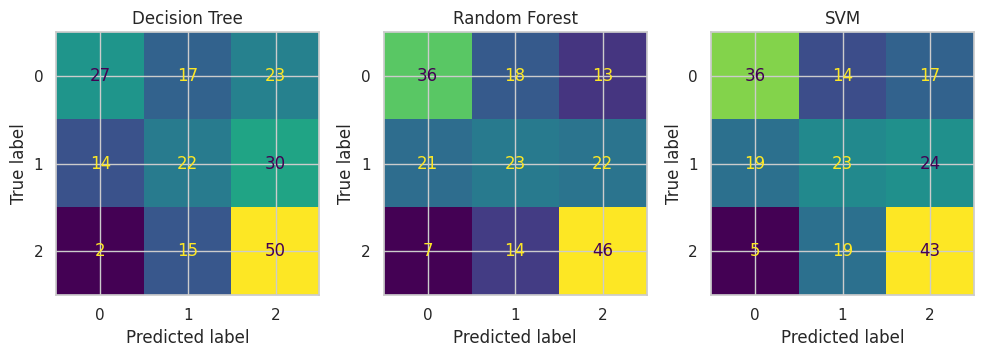

In [115]:
#confusion matrices side by side
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

Interpretation = Class 1 is unlearnable. Read the middle row of each: 14/22/30, then 21/23/22, then 19/23/24. All three land on 22–23 correct out of 66, and the misses spread almost evenly left and right. Three different algorithm families converging on the same result means the problem is the features, not the model.

Corner cells confirm ordinal structure. True 2 predicted as 0 happens only 2, 7, and 5 times. True 0 predicted as 2 is 23, 13, and 17. Confusion concentrates between neighbouring bands, not across the full range — the classes are ordered, and the models are getting the direction roughly right even when they miss the exact band.
Decision Tree over-predicts class 2. Sum its right-hand column: 23+30+50 = 103 predictions of class 2 when only 67 rows are class 2. That inflated recall on class 2 (50/67) is bought by dumping uncertain cases there. Random Forest and SVM spread their predictions more evenly, which is why their per-class scores looked more balanced even though overall accuracy was similar.

Class 0 is where they differ. Decision Tree gets 27 right, the other two get 36 each. That's the single biggest gap between models on this figure.

All three models handle the extreme bands acceptably and fail on the middle band identically, which caps overall accuracy near 0.53 and points to insufficient feature separation rather than model choice.


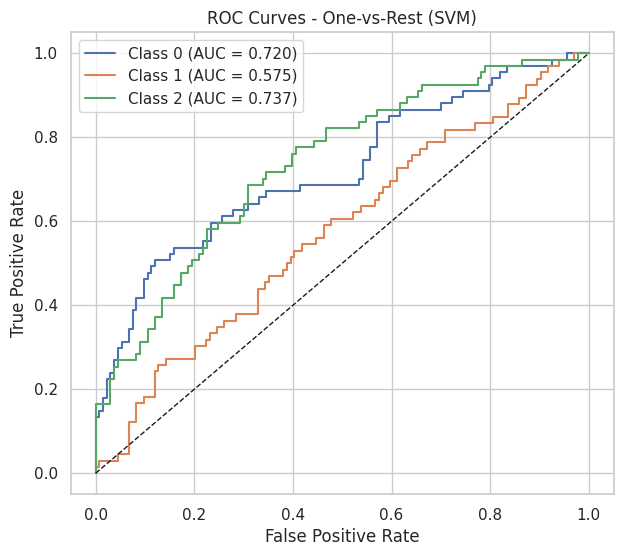

In [119]:
#Multiclass ROC need one vs rest binarize the labels and draw one curve per class
from sklearn.metrics import roc_curve, auc
model = models['SVM']
classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)   # shape (n_samples, n_classes)
y_scores = model.decision_function(X_test)             # same shape, ovr by default

plt.figure(figsize=(7, 6))
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    plt.plot(fpr, tpr, label=f"Class {c} (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - One-vs-Rest (SVM)")
plt.legend()
plt.show()


In [120]:
#target turn out to be numeric
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name:15} RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.3f}  "
          f"MAE: {mean_absolute_error(y_test, pred):.3f}  R²: {r2_score(y_test, pred):.3f}")

Decision Tree   RMSE: 0.938  MAE: 0.630  R²: -0.313
Random Forest   RMSE: 0.880  MAE: 0.575  R²: -0.157
SVM             RMSE: 0.906  MAE: 0.600  R²: -0.224


#Part 4: Model Interpretation and Inference:
1. Provide a detailed interpretation of the model results. Discuss which model performed best and why based on the metrics.
2. Visualize the results using confusion matrices, ROC curves, or other relevant plots.

Interpretation of ROC Curves= Classes 0 and 2 have real signal. AUC 0.720 and 0.737 is decent, far above the 0.5 diagonal. AUC asks: pick a random class 2 row and a random non-class 2 row, how often does the model score the class2 one higher? About 74% of the time. That's meaningfully better than the ~0.51 accuracy suggested.
Class 1 is barely above chance at 0.575. Its curve hugs the diagonal through the whole left half. This is the same finding as the confusion matrices, now quantified: the model cannot rank middle-band rows apart from the rest.

The ordinal structure means a plain classification metric understates the model, being off by one adjacent band is a much smaller error than the confusion matrix treats it as. Second, this supports the binary experiment I mentioned earlier: collapse to low vs high, drop or merge the middle, and you'd likely see accuracy jump substantially, because that's essentially what these two outer AUC curves are already telling you.

#Part 5: Deployment and Monitoring:
1. Propose a method for deploying the best-performing model into a production environment.
2. Discuss potential issues that could arise during deployment and operation, including how to handle incoming real-time data.
3. Suggest strategies for ongoing monitoring and maintenance of the model.

#1. Propose a method for deploying the best-performing model into a production environment.
The best is wrap everything hosted in cloud enviroments and accessible via APIs (REST APIs). Model file , training data snapshot, and code all get a version tag, and the API returns its model version with each prediction. Without this you can't explain why last month's prediction differed from today's.

#2. Discuss potential issues that could arise during deployment and operation, including how to handle incoming real-time data.
- During the distribution classes I used the pd.cut on the full dataset before splitting is technically targete leakage into the bin edges.
- Missing and malformed input, real requests arrive with nulls, wrong types, strings where numbers belongs, and out of range values like years experience = 200.

#3. Suggest strategies for ongoing monitoring and maintenance of the model.
- request volumne, latency percentiles error rates, uptime. Standard application monitoring.
- Prediction drift, track the distribution of predicted bands over time. If the model suddenly predicts "Very High" for 40% of records when it used to be 25%, something changed even before you have ground truth to confirm it.